# Анализ результатов онлайн-олимпиады для школьников

Структура ноутбука:
1. Импорт библиотек и настройка отображения
2. Загрузка данных
3. Первичный осмотр
4. Поиск проблем в данных
5. Очистка данных
6. Обогащение данных
7. Анализ сложности заданий
8. Описание аудитории
9. Региональные мини-отчёты
10. Связь времени и точности
11. Корреляция между заданиями
12. Кластеризация учеников
13. Ключевые выводы и рекомендации

## 1. Импорт библиотек

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14

COLOR_MAIN = '#4C72B0'     # синий
COLOR_ACCENT = '#C44E52'   # красный
COLOR_GOOD = '#55A868'     # зелёный

task_labels = {f'Task_{n}_correct': f'Задание {n}' for n in range(1, 13)}

## 2. Загрузка данных

In [7]:
df = pd.read_csv('olympiad_results.csv', parse_dates=['start_time', 'end_time'])
dict_df = pd.read_csv('olympiad_data_dictionary.csv')

print('Форма таблицы результатов:', df.shape)

Форма таблицы результатов: (8037, 46)


In [8]:
# словарь данных
display(dict_df)

,Столбец,Описание
0,student_id,Уникальный идентификатор ученика
1,region,Регион школы ученика (содержит опечатки и разные написания одного региона)
2,school_number,Номер школы внутри региона
3,grade,Класс ученика (5-11)
4,start_time,Время начала прохождения олимпиады
5,end_time,Время окончания прохождения олимпиады
6,Task_N_answer,Выбранный вариант ответа на задание N (1-4)
7,Task_N_correct,"Признак правильности ответа на задание N (1 - верно, 0 - неверно, NaN - пропущено)"
8,Task_N_time_spent,"Время, затраченное на задание N, в секундах"
9,total_score,"Итоговый балл за олимпиаду (в части строк тип данных - строка, а не число)"


## 3. Первичный осмотр данных

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8037 entries, 0 to 8036
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   student_id          8037 non-null   str           
 1   region              8037 non-null   str           
 2   school_number       8037 non-null   int64         
 3   grade               8037 non-null   int64         
 4   start_time          8037 non-null   datetime64[us]
 5   end_time            8037 non-null   datetime64[us]
 6   Task_1_answer       7719 non-null   float64       
 7   Task_1_correct      7719 non-null   float64       
 8   Task_1_time_spent   7719 non-null   float64       
 9   Task_2_answer       7696 non-null   float64       
 10  Task_2_correct      7696 non-null   float64       
 11  Task_2_time_spent   7696 non-null   float64       
 12  Task_3_answer       7722 non-null   float64       
 13  Task_3_correct      7722 non-null   float64       
 14  Tas

In [10]:
df.head()

,student_id,region,school_number,grade,start_time,end_time,Task_1_answer,Task_1_correct,Task_1_time_spent,Task_2_answer,Task_2_correct,Task_2_time_spent,Task_3_answer,Task_3_correct,Task_3_time_spent,Task_4_answer,Task_4_correct,Task_4_time_spent,Task_5_answer,Task_5_correct,Task_5_time_spent,Task_6_answer,Task_6_correct,Task_6_time_spent,Task_7_answer,Task_7_correct,Task_7_time_spent,Task_8_answer,Task_8_correct,Task_8_time_spent,Task_9_answer,Task_9_correct,Task_9_time_spent,Task_10_answer,Task_10_correct,Task_10_time_spent,Task_11_answer,Task_11_correct,Task_11_time_spent,Task_12_answer,Task_12_correct,Task_12_time_spent,total_score,device_type,attempts_count,disconnects
0,S200000,Краснодар,9,11,2026-04-10 11:10:00,2026-04-10 11:25:19,4.0,0.0,93.0,1.0,0.0,75.0,2.0,0.0,65.0,1.0,0.0,81.0,1.0,0.0,66.0,1.0,0.0,47.0,2.0,0.0,109.0,3.0,1.0,30.0,3.0,1.0,59.0,1.0,1.0,86.0,2.0,0.0,84.0,4.0,0.0,124.0,3,desktop,2,0
1,S200001,Ростов-на-Дону,44,9,2026-04-10 10:30:00,2026-04-10 10:44:19,3.0,0.0,105.0,2.0,0.0,71.0,2.0,0.0,59.0,1.0,1.0,117.0,3.0,0.0,59.0,3.0,1.0,60.0,4.0,1.0,67.0,1.0,1.0,76.0,1.0,0.0,33.0,2.0,1.0,76.0,4.0,1.0,73.0,4.0,0.0,63.0,6,mobile,2,0
2,S200002,Екатеринбург,44,9,2026-04-10 10:25:00,2026-04-10 10:38:33,4.0,1.0,60.0,3.0,0.0,98.0,2.0,0.0,67.0,1.0,1.0,26.0,3.0,0.0,86.0,3.0,1.0,81.0,4.0,1.0,84.0,2.0,1.0,71.0,1.0,0.0,62.0,NaN,NaN,NaN,1.0,1.0,101.0,1.0,1.0,77.0,7,mobile,1,1
3,S200003,Казань,44,11,2026-04-10 10:04:00,2026-04-10 10:18:18,1.0,0.0,58.0,1.0,1.0,91.0,4.0,0.0,63.0,2.0,1.0,59.0,2.0,1.0,71.0,4.0,0.0,5.0,1.0,0.0,57.0,2.0,1.0,80.0,1.0,0.0,95.0,2.0,0.0,93.0,4.0,0.0,100.0,3.0,1.0,86.0,5,mobile,1,0
4,S200004,Уфа,26,9,2026-04-10 10:53:00,2026-04-10 11:08:36,4.0,0.0,111.0,1.0,1.0,74.0,2.0,0.0,59.0,4.0,1.0,111.0,3.0,0.0,24.0,2.0,0.0,59.0,3.0,1.0,36.0,1.0,1.0,93.0,3.0,1.0,71.0,1.0,1.0,123.0,4.0,0.0,79.0,2.0,0.0,96.0,6,mobile,2,0


In [11]:
df.describe()

,school_number,grade,start_time,end_time,Task_1_answer,Task_1_correct,Task_1_time_spent,Task_2_answer,Task_2_correct,Task_2_time_spent,Task_3_answer,Task_3_correct,Task_3_time_spent,Task_4_answer,Task_4_correct,Task_4_time_spent,Task_5_answer,Task_5_correct,Task_5_time_spent,Task_6_answer,Task_6_correct,Task_6_time_spent,Task_7_answer,Task_7_correct,Task_7_time_spent,Task_8_answer,Task_8_correct,Task_8_time_spent,Task_9_answer,Task_9_correct,Task_9_time_spent,Task_10_answer,Task_10_correct,Task_10_time_spent,Task_11_answer,Task_11_correct,Task_11_time_spent,Task_12_answer,Task_12_correct,Task_12_time_spent,total_score,attempts_count,disconnects
count,8037.000000,8037.000000,8037,8037,7719.000000,7719.000000,7719.000000,7696.000000,7696.000000,7696.000000,7722.000000,7722.000000,7722.000000,7727.000000,7727.000000,7727.000000,7738.000000,7738.000000,7738.000000,7710.000000,7710.000000,7710.000000,7725.000000,7725.000000,7725.000000,7721.000000,7721.000000,7721.000000,7724.000000,7724.000000,7724.000000,7721.000000,7721.000000,7721.000000,7750.000000,7750.000000,7750.000000,7716.00000,7716.000000,7716.000000,8037.000000,8037.000000,8037.000000
mean,29.989797,8.009830,2026-04-10 10:30:13.893243,2026-04-10 10:44:13.708349,2.509522,0.296671,63.525327,2.491294,0.377469,68.488046,2.518519,0.337218,65.448459,2.517924,0.588974,78.070014,2.491471,0.634919,80.486431,2.510117,0.449546,71.087030,2.496052,0.583042,78.343301,2.503950,0.596425,78.840824,2.480321,0.319524,65.276670,2.501489,0.529595,75.193498,2.498323,0.465161,72.092516,2.51633,0.567911,77.140747,5.522210,1.489735,0.192485
min,1.000000,5.000000,2026-04-10 09:00:00,2026-04-10 09:00:24,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,15.000000,6.000000,2026-04-10 09:46:00,2026-04-10 09:59:42,1.000000,0.000000,47.000000,2.000000,0.000000,52.000000,2.000000,0.000000,48.000000,2.000000,0.000000,61.000000,1.000000,0.000000,64.000000,2.000000,0.000000,54.000000,1.000000,0.000000,62.000000,1.000000,0.000000,62.000000,1.000000,0.000000,48.000000,2.000000,0.000000,58.000000,1.000000,0.000000,55.000000,2.00000,0.000000,60.000000,3.000000,1.000000,0.000000
50%,30.000000,8.000000,2026-04-10 10:31:00,2026-04-10 10:44:33,3.000000,0.000000,63.000000,2.000000,0.000000,69.000000,3.000000,0.000000,66.000000,3.000000,1.000000,78.000000,2.000000,1.000000,81.000000,3.000000,0.000000,71.000000,3.000000,1.000000,79.000000,3.000000,1.000000,80.000000,2.000000,0.000000,65.000000,2.000000,1.000000,75.000000,3.000000,0.000000,72.000000,3.00000,1.000000,77.000000,5.000000,1.000000,0.000000
75%,45.000000,10.000000,2026-04-10 11:15:00,2026-04-10 11:29:28,4.000000,1.000000,81.000000,3.000000,1.000000,86.000000,4.000000,1.000000,83.000000,4.000000,1.000000,95.000000,3.000000,1.000000,97.000000,3.000000,1.000000,88.000000,3.000000,1.000000,96.000000,4.000000,1.000000,96.000000,3.000000,1.000000,82.000000,3.000000,1.000000,92.000000,4.000000,1.000000,89.000000,4.00000,1.000000,94.000000,8.000000,2.000000,0.000000
max,59.000000,11.000000,2026-04-10 11:59:00,2026-04-10 12:16:44,4.000000,1.000000,167.000000,4.000000,1.000000,150.000000,4.000000,1.000000,156.000000,4.000000,1.000000,171.000000,4.000000,1.000000,168.000000,4.000000,1.000000,161.000000,4.000000,1.000000,185.000000,4.000000,1.000000,161.000000,4.000000,1.000000,159.000000,4.000000,1.000000,164.000000,4.000000,1.000000,172.000000,4.00000,1.000000,191.000000,12.000000,2.000000,4.000000
std,17.184086,1.997205,NaN,NaN,1.120323,0.456820,25.438295,1.116793,0.484785,25.352555,1.109814,0.472791,25.411903,1.119871,0.492052,26.179944,1.117842,0.481484,25.926326,1.113410,0.497480,25.473059,1.118041,0.493088,26.020427,1.123474,0.490646,25.805604,1.124285,0.466322,

## 4. Поиск проблем в данных

### 4.1 Пропуски

In [12]:
na_counts = df.isna().sum()
na_counts[na_counts > 0]

Task_1_answer         318
Task_1_correct        318
Task_1_time_spent     318
Task_2_answer         341
Task_2_correct        341
Task_2_time_spent     341
Task_3_answer         315
Task_3_correct        315
Task_3_time_spent     315
Task_4_answer         310
Task_4_correct        310
Task_4_time_spent     310
Task_5_answer         299
Task_5_correct        299
Task_5_time_spent     299
Task_6_answer         327
Task_6_correct        327
Task_6_time_spent     327
Task_7_answer         312
Task_7_correct        312
Task_7_time_spent     312
Task_8_answer         316
Task_8_correct        316
Task_8_time_spent     316
Task_9_answer         313
Task_9_correct        313
Task_9_time_spent     313
Task_10_answer        316
Task_10_correct       316
Task_10_time_spent    316
Task_11_answer        287
Task_11_correct       287
Task_11_time_spent    287
Task_12_answer        321
Task_12_correct       321
Task_12_time_spent    321
dtype: int64

Пропуски есть в столбцах по каждому заданию, примерно 300 строк (4%) на задание. Скорее всего, это ученики, которые не успели или не стали отвечать на конкретное задание. Это не технический сбой, а часть картины, поэтому не будем удалять строки.

### 4.2 Дубликаты

In [13]:
print('Полные дубли строк:', df.duplicated().sum())
print('Дубли по student_id:', df.duplicated(subset='student_id').sum())

Полные дубли строк: 37
Дубли по student_id: 37


### 4.3 Опечатки в регионах

In [14]:
sorted(df['region'].unique())

['Moskva',
 'Воронеж',
 'Екатеринбург',
 'Казань',
 'Краснодар',
 'Москва',
 'Новосибирск',
 'Пермь',
 'Ростов-на-Дону',
 'СПб',
 'Санкт Петербург',
 'Санкт-Петербург',
 'Уфа',
 'г. Москва',
 'г.Казань',
 'казань',
 'москва',
 'мск',
 'спб']

Один и тот же регион записан по-разному. Например, "Москва", "москва", "мск", "Moskva" и "г. Москва". Список вариантов на Москву, Санкт-Петербург и Казань придётся свести к единому написанию.

### 4.4 Аномально быстрые прохождения

In [15]:
df['duration_minutes'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df['duration_minutes'].describe()

count    8037.000000
mean       13.996918
std         2.083434
min         0.300000
25%        13.000000
50%        14.133333
75%        15.216667
max        19.566667
Name: duration_minutes, dtype: float64

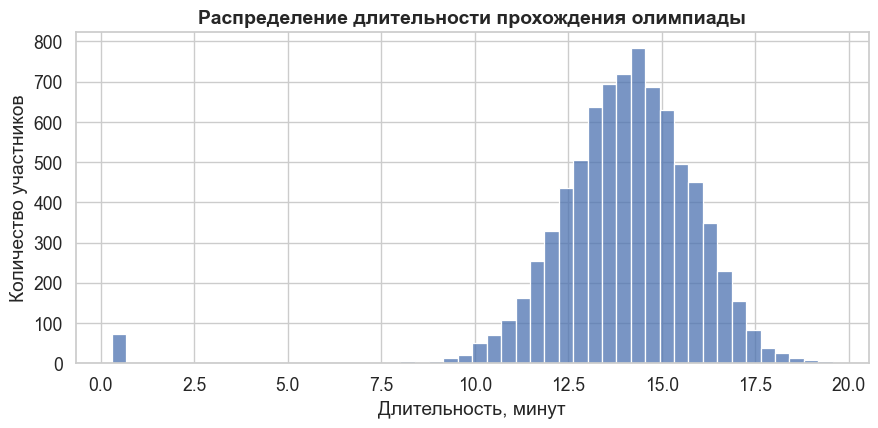

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df['duration_minutes'], bins=50, ax=ax, color=COLOR_MAIN)
ax.set_title('Распределение длительности прохождения олимпиады')
ax.set_xlabel('Длительность, минут')
ax.set_ylabel('Количество участников')
plt.tight_layout()
plt.show()

In [17]:
# смотрим на самые быстрые прохождения
df['duration_minutes'].sort_values().head(15)

2341    0.300000
2692    0.316667
1158    0.316667
483     0.333333
648     0.333333
1449    0.333333
1595    0.333333
2671    0.350000
7101    0.350000
5021    0.350000
3289    0.350000
1110    0.350000
6432    0.350000
2411    0.350000
1444    0.350000
Name: duration_minutes, dtype: float64

Виден явный разрыв, ведь часть сессий длится меньше минуты, а следующее по скорости прохождение уже больше 7 минут. Это похоже на технические или тестовые сессии, поэтому уберём их при очистке данных.

In [18]:
anomaly_threshold_min = 1  # минута — подобрано по разрыву в распределении выше

fast_sessions = df[df['duration_minutes'] < anomaly_threshold_min]
print(f'Аномально быстрых прохождений: {len(fast_sessions)}')
fast_sessions[['student_id', 'region', 'device_type', 'attempts_count', 'duration_minutes']].head()

Аномально быстрых прохождений: 73


,student_id,region,device_type,attempts_count,duration_minutes
74,S200074,Новосибирск,desktop,1,0.400000
360,S200359,Казань,desktop,1,0.416667
465,S200464,Санкт-Петербург,mobile,1,0.400000
483,S200482,Казань,desktop,1,0.333333
503,S200502,Новосибирск,desktop,1,0.383333


## 5. Очистка данных

### 5.1 Удаляем полные дубликаты

In [19]:
rows_before = len(df)
df = df.drop_duplicates()
print(f'Удалено дублей: {rows_before - len(df)}')

Удалено дублей: 37


### 5.2 Приводим регионы к единому написанию

In [20]:
region_mapping = {
    'moskva': 'Москва',
    'москва': 'Москва',
    'мск': 'Москва',
    'г. москва': 'Москва',
    'г.москва': 'Москва',
    'спб': 'Санкт-Петербург',
    'санкт петербург': 'Санкт-Петербург',
    'санкт-петербург': 'Санкт-Петербург',
    'казань': 'Казань',
    'г.казань': 'Казань',
    'г. казань': 'Казань',
}

def clean_region(value):
    key = str(value).strip().lower()
    return region_mapping.get(key, str(value).strip())

df['region'] = df['region'].apply(clean_region)
sorted(df['region'].unique())

['Воронеж',
 'Екатеринбург',
 'Казань',
 'Краснодар',
 'Москва',
 'Новосибирск',
 'Пермь',
 'Ростов-на-Дону',
 'Санкт-Петербург',
 'Уфа']

Проверка:

In [21]:
print('Количество регионов после очистки:', df['region'].nunique())
df['region'].value_counts()

Количество регионов после очистки: 10


region
Уфа                843
Москва             830
Казань             821
Краснодар          806
Воронеж            803
Санкт-Петербург    801
Ростов-на-Дону     796
Новосибирск        786
Пермь              763
Екатеринбург       751
Name: count, dtype: int64

### 5.3 Удаляем аномально быстрые сессии

In [22]:
rows_before = len(df)
df = df[df['duration_minutes'] >= anomaly_threshold_min].reset_index(drop=True)
print(f'Удалено аномальных сессий: {rows_before - len(df)}')
print(f'Итоговый размер таблицы: {df.shape}')

Удалено аномальных сессий: 72
Итоговый размер таблицы: (7928, 47)


### 5.4 Проверка согласованности `total_score`

В словаре данных указано, что часть значений `total_score` может быть строкового типа. Проверим, совпадает ли `total_score` с суммой правильных ответов по заданиям (`Task_N_correct`), и заодно убедимся, что тип данных числовой.

In [23]:
task_correct_cols = [c for c in df.columns if c.endswith('_correct')]

df['computed_score'] = df[task_correct_cols].sum(axis=1)
mismatch = df[df['total_score'] != df['computed_score']]

print('Тип столбца total_score:', df['total_score'].dtype)
print('Строк с расхождением total_score и суммы правильных ответов:', len(mismatch))
mismatch[['student_id', 'total_score', 'computed_score']].head()

Тип столбца total_score: int64
Строк с расхождением total_score и суммы правильных ответов: 0


,student_id,total_score,computed_score


## 6. Обогащение данных

Считаем новые метрики, которые понадобятся для анализа:
- количество заданий, на которые ученик ответил
- доля правильных ответов
- среднее время на одно задание

In [24]:
task_answer_cols = [c for c in df.columns if c.endswith('_answer')]
task_time_cols = [c for c in df.columns if c.endswith('_time_spent')]

df['tasks_attempted'] = df[task_answer_cols].notna().sum(axis=1)
df['accuracy_pct'] = (df['computed_score'] / df['tasks_attempted'] * 100).round(1)
df['avg_time_per_task'] = df[task_time_cols].mean(axis=1).round(1)

df[['student_id', 'tasks_attempted', 'computed_score', 'accuracy_pct', 'avg_time_per_task']].head()

,student_id,tasks_attempted,computed_score,accuracy_pct,avg_time_per_task
0,S200000,12,3.0,25.0,76.6
1,S200001,12,6.0,50.0,71.6
2,S200002,11,7.0,63.6,73.9
3,S200003,12,5.0,41.7,71.5
4,S200004,12,6.0,50.0,78.0


## 7. Анализ сложности заданий

Для каждого задания считаем: долю правильных ответов и среднее время выполнения.

In [25]:
task_stats = []
for n in range(1, 13):
    correct_col = f'Task_{n}_correct'
    time_col = f'Task_{n}_time_spent'
    task_stats.append({
        'Задание': f'Задание {n}',
        '% решаемости': round(df[correct_col].mean(skipna=True) * 100, 1),
        'Среднее время, сек': round(df[time_col].mean(skipna=True), 1),
        'Отвечали, чел.': int(df[correct_col].notna().sum()),
    })

task_stats_df = pd.DataFrame(task_stats).sort_values('% решаемости').reset_index(drop=True)
task_stats_df

,Задание,% решаемости,"Среднее время, сек","Отвечали, чел."
0,Задание 1,29.8,64.1,7610
1,Задание 9,32.0,65.9,7619
2,Задание 3,33.9,66.0,7614
3,Задание 2,37.8,69.1,7588
4,Задание 6,45.1,71.7,7602
5,Задание 11,46.7,72.8,7642
6,Задание 10,53.3,75.9,7613
7,Задание 12,57.2,77.8,7611
8,Задание 7,58.7,79.1,7619
9,Задание 4,59.2,78.8,7621


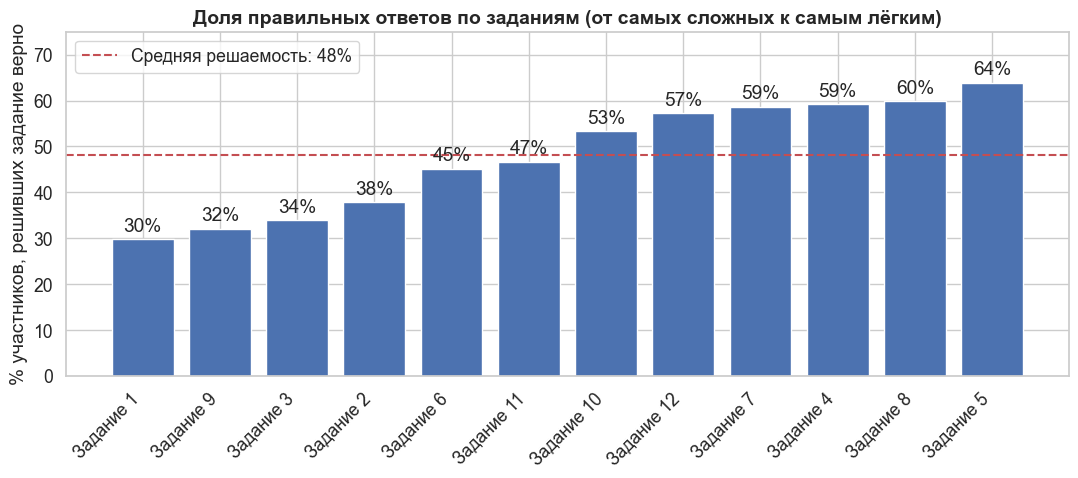

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(task_stats_df['Задание'], task_stats_df['% решаемости'], color=COLOR_MAIN)
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.axhline(task_stats_df['% решаемости'].mean(), color=COLOR_ACCENT, linestyle='--', linewidth=1.5,
           label=f"Средняя решаемость: {task_stats_df['% решаемости'].mean():.0f}%")
ax.set_title('Доля правильных ответов по заданиям (от самых сложных к самым лёгким)')
ax.set_ylabel('% участников, решивших задание верно')
ax.set_xlabel('')
ax.set_ylim(0, 75)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

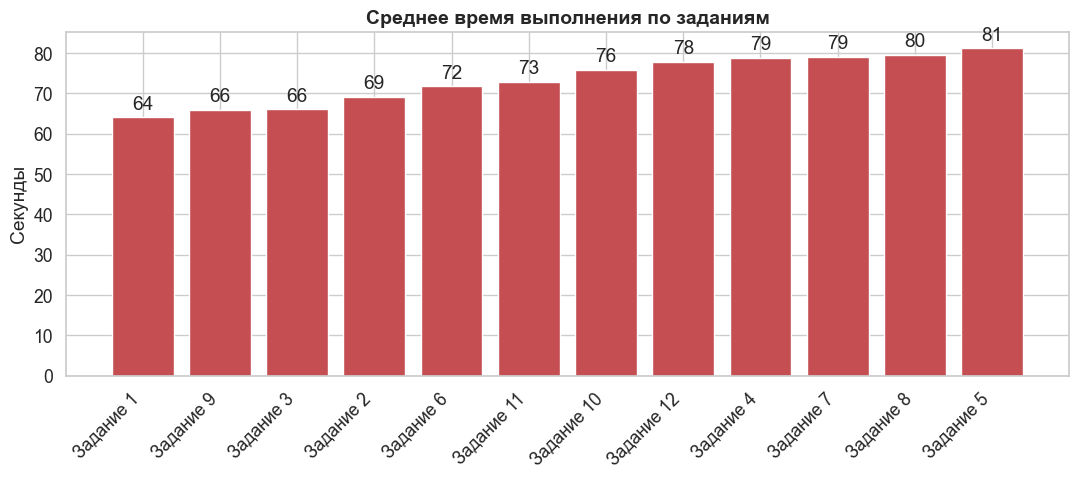

In [27]:
order = task_stats_df.sort_values('Среднее время, сек')['Задание']
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(order, task_stats_df.set_index('Задание').loc[order, 'Среднее время, сек'], color=COLOR_ACCENT)
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set_title('Среднее время выполнения по заданиям')
ax.set_ylabel('Секунды')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Самые сложные задания для участников — Задание 1, Задание 9 и Задание 3 (решаемость 30–34%). Самые лёгкие — Задание 5, Задание 8 и Задание 4 (решаемость 58–64%). При планировании следующей олимпиады стоит перечитать формулировки трёх самых сложных заданий — возможно, дело не в сложности содержания, а в непонятной постановке вопроса.

## 8. Описание аудитории олимпиады

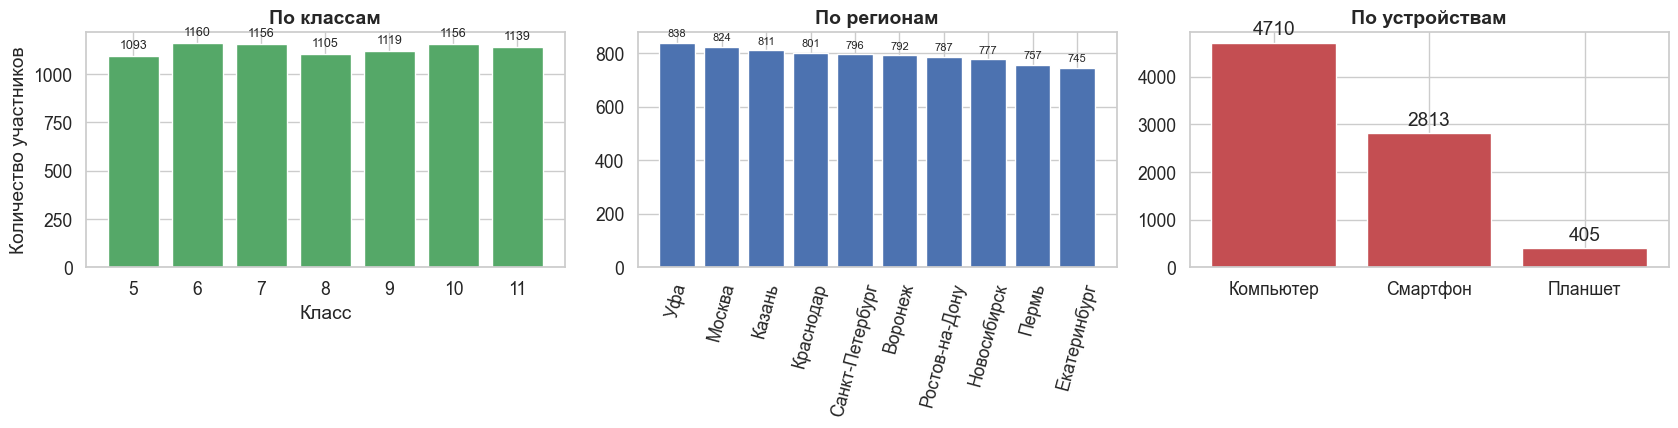

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

grade_counts = df['grade'].value_counts().sort_index()
bars0 = axes[0].bar(grade_counts.index.astype(str), grade_counts.values, color=COLOR_GOOD)
axes[0].bar_label(bars0, padding=3, fontsize=9)
axes[0].set_title('По классам')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество участников')

region_counts = df['region'].value_counts()
bars1 = axes[1].bar(region_counts.index, region_counts.values, color=COLOR_MAIN)
axes[1].bar_label(bars1, padding=3, fontsize=8)
axes[1].set_title('По регионам')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=75)

device_ru = {'desktop': 'Компьютер', 'mobile': 'Смартфон', 'tablet': 'Планшет'}
device_counts = df['device_type'].map(device_ru).value_counts()
bars2 = axes[2].bar(device_counts.index, device_counts.values, color=COLOR_ACCENT)
axes[2].bar_label(bars2, padding=3)
axes[2].set_title('По устройствам')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

Участники распределены равномерно по классам и регионам, сравнения по группам не искажены разным количеством участников. Почти 60% заходят с компьютера, треть - со смартфона.

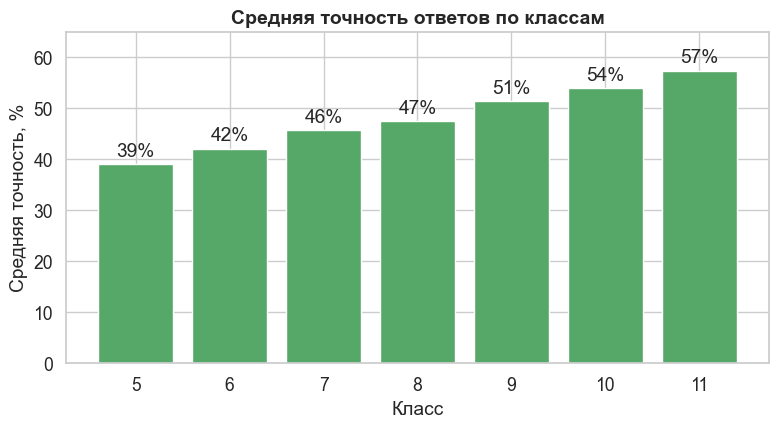

In [29]:
accuracy_by_grade = df.groupby('grade')['accuracy_pct'].mean().round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(accuracy_by_grade.index.astype(str), accuracy_by_grade.values, color=COLOR_GOOD)
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_title('Средняя точность ответов по классам')
ax.set_xlabel('Класс')
ax.set_ylabel('Средняя точность, %')
ax.set_ylim(0, 65)
plt.tight_layout()
plt.show()

Точность ответов растёт равномерно от 5 к 11 классу, соответственно, задания корректно масштабированы по сложности для разных возрастов, резких провалов нет или слишком тяжелых вариантов нет.

## 9. Региональные мини-отчёты и сравнение регионов

Функция ниже строит сводку по одному региону: количество участников, средний балл, топ школ по среднему баллу, распределение по классам. Дальше — сравнение всех регионов между собой и проверка, насколько эти различия вообще значимы статистически.

Регион: Москва
Участников: 824
Средний балл: 5.66 из 12
Средняя доля правильных ответов: 49.2%

Топ-5 школ по среднему баллу (от 3 участников):


,Участников,Средний балл
school_number,,
26,10,7.50
4,14,7.36
43,12,6.83
34,19,6.79
28,16,6.75


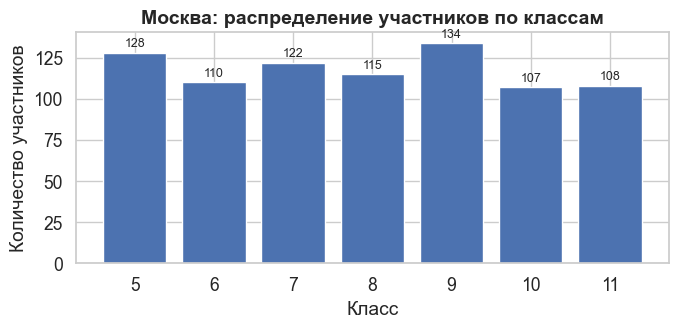

,Участников,Средний балл
school_number,,
26,10,7.500000
4,14,7.357143
43,12,6.833333
34,19,6.789474
28,16,6.750000


In [30]:
def regional_report(region_name, top_n_schools=5):
    subset = df[df['region'] == region_name]

    if subset.empty:
        print(f'Регион "{region_name}" не найден в данных.')
        return None

    print(f'Регион: {region_name}')
    print(f'Участников: {len(subset)}')
    print(f'Средний балл: {subset["total_score"].mean():.2f} из 12')
    print(f'Средняя доля правильных ответов: {subset["accuracy_pct"].mean():.1f}%')
    print()

    print(f'Топ-{top_n_schools} школ по среднему баллу (от 3 участников):')
    school_stats = (
        subset.groupby('school_number')
        .agg(**{'Участников': ('student_id', 'count'), 'Средний балл': ('total_score', 'mean')})
        .query('Участников >= 3')
        .sort_values('Средний балл', ascending=False)
        .head(top_n_schools)
    )
    display(school_stats.round(2))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    grade_dist = subset['grade'].value_counts().sort_index()
    bars = ax.bar(grade_dist.index.astype(str), grade_dist.values, color=COLOR_MAIN)
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(f'{region_name}: распределение участников по классам')
    ax.set_xlabel('Класс')
    ax.set_ylabel('Количество участников')
    plt.tight_layout()
    plt.show()

    return school_stats

regional_report('Москва')

In [31]:
# сводная таблица по всем регионам
region_summary = (
    df.groupby('region')
    .agg(**{
        'Участников': ('student_id', 'count'),
        'Средний балл (из 12)': ('total_score', 'mean'),
        'Средняя точность, %': ('accuracy_pct', 'mean'),
        'Среднее время, мин': ('duration_minutes', 'mean'),
    })
    .round(2)
    .sort_values('Средний балл (из 12)', ascending=False)
)
region_summary.index.name = 'Регион'
region_summary

,Участников,Средний балл (из 12),"Средняя точность, %","Среднее время, мин"
Регион,,,,
Новосибирск,777,5.73,49.77,14.18
Москва,824,5.66,49.24,14.10
Екатеринбург,745,5.62,48.75,14.13
Ростов-на-Дону,787,5.60,48.46,14.23
Санкт-Петербург,796,5.58,48.20,14.09
Воронеж,792,5.50,47.64,14.12
Уфа,838,5.49,47.61,14.06
Казань,811,5.48,47.75,14.07
Краснодар,801,5.43,47.21,14.10


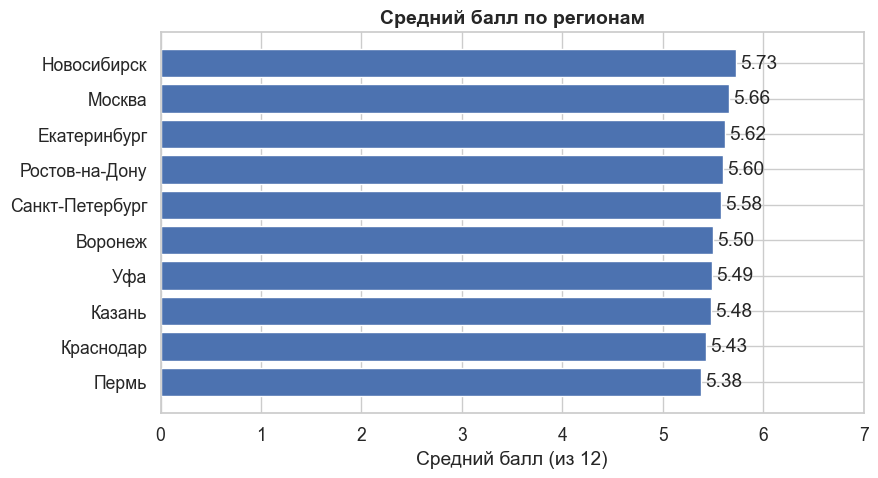

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(region_summary.index[::-1], region_summary['Средний балл (из 12)'][::-1], color=COLOR_MAIN)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_title('Средний балл по регионам')
ax.set_xlabel('Средний балл (из 12)')
ax.set_xlim(0, 7)
plt.tight_layout()
plt.show()

Разница между лучшим и худшим регионом - меньше одного балла из 12. Проверим тестом ANOVA, реальна ли эта разница, или это просто случайный разброс выборки.

In [33]:
groups = [g['accuracy_pct'].values for _, g in df.groupby('region')]
f_stat, p_value = stats.f_oneway(*groups)

grand_mean = df['accuracy_pct'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((df['accuracy_pct'] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

print(f'ANOVA: F = {f_stat:.2f}, p-value = {p_value:.3f}')
print(f'Доля различий в результатах, объясняемая регионом: {eta_squared * 100:.2f}%')

ANOVA: F = 1.23, p-value = 0.269
Доля различий в результатах, объясняемая регионом: 0.14%


P-value значительно больше 0.05, значит, статистически значимой разницы между регионами нет. Регион объясняет менее 0.2% различий в результатах учеников.

Нет необходимости делать разные по сложности версии олимпиады для разных регионов, т.к. уровень подготовки участников сопоставим по всей стране.

## 10. Связь времени и точности

Раньше мы увидели почти идеальную корреляцию (r = 0.998) между средним временем и % решаемости.

Возможно:
1. конкретные задания устроены так, что дольше = точнее
2. в среднем более сильные ученики тратят больше времени вообще на всё

Проверим гипотезу 2.

In [34]:
r, p = stats.pearsonr(df['avg_time_per_task'], df['accuracy_pct'])
slope, intercept, r_value, p_value, std_err = stats.linregress(df['avg_time_per_task'], df['accuracy_pct'])

print(f'Корреляция Пирсона: r = {r:.3f}, p-value = {p:.3f}')
print(f'R² линейной регрессии: {r_value**2:.4f}')
print(f'Наклон: {slope:.3f} п.п. точности на каждую доп. секунду среднего времени')

Корреляция Пирсона: r = -0.009, p-value = 0.444
R² линейной регрессии: 0.0001
Наклон: -0.028 п.п. точности на каждую доп. секунду среднего времени


На уровне учеников корреляция практически нулевая (r = -0.009, p > 0.05 — статистически не значимо). Гипотеза (2) не подтвердилась: сильные ученики в среднем не тратят больше времени на задания в целом.

Похоже на гипотезу (1): задания с низкой решаемостью (Задание 1, 9, 3) заставляют давать быстрые и неточные ответы.
 
Рекомендация: пересмотреть формулировки именно этих трёх заданий перед следующим запуском.

## 11. Корреляция между заданиями

Проверим, есть ли задания, которые измеряют один и тот же навык (сильно коррелируют друг с другом), или наоборот - задания, слабо связанные друг с другом

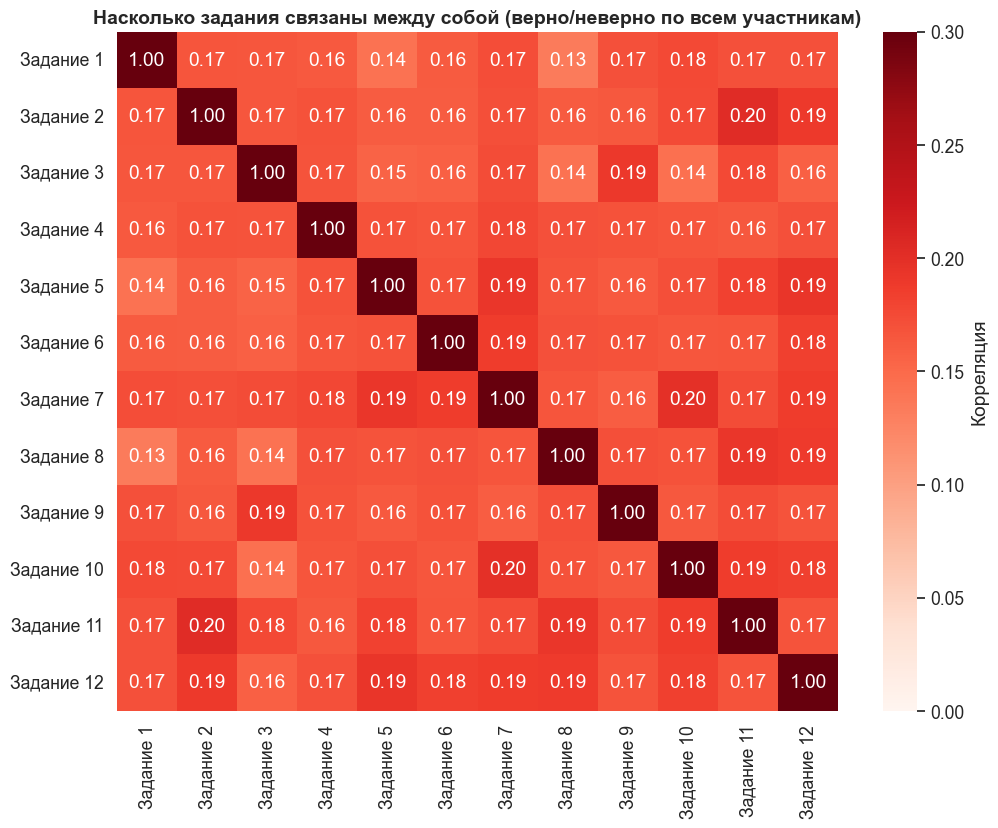

In [36]:
task_corr = df[task_correct_cols].corr()
task_corr_display = task_corr.rename(index=task_labels, columns=task_labels)

fig, ax = plt.subplots(figsize=(10.5, 8.5))
sns.heatmap(task_corr_display, annot=True, fmt='.2f', cmap='Reds', ax=ax, vmin=0, vmax=0.3,
            cbar_kws={'label': 'Корреляция'})
ax.set_title('Насколько задания связаны между собой (верно/неверно по всем участникам)')
plt.tight_layout()
plt.show()

In [37]:
corr_pairs = task_corr.where(np.triu(np.ones(task_corr.shape), k=1).astype(bool)).stack().dropna().sort_values()

print('Диапазон корреляций (без диагонали):', round(corr_pairs.min(), 2), '—', round(corr_pairs.max(), 2))
print()
print('Самые слабые связи:')
print(corr_pairs.head(3))
print()
print('Самые сильные связи:')
print(corr_pairs.tail(3))

Диапазон корреляций (без диагонали): 0.13 — 0.2

Самые слабые связи:
Task_1_correct  Task_8_correct    0.134683
Task_3_correct  Task_8_correct    0.142735
Task_1_correct  Task_5_correct    0.142791
dtype: float64

Самые сильные связи:
Task_5_correct  Task_12_correct    0.194350
Task_7_correct  Task_10_correct    0.198947
Task_2_correct  Task_11_correct    0.203427
dtype: float64


Все попарные связи укладываются в узкий диапазон 0.13...0.20, значит задания достаточно однородно связаны друг с другом. Нет ни явных пар (корреляция ближе к 1), ни полностью отличных от остальных (корреляция ближе к 0). 

Банк заданий хорошо сбалансирован, ни одно задание не стоит убирать как избыточное.

## 12. Кластеризация учеников

Попробуем найти типажи учеников. Кластеризуем по вектору правильности ответов для каждого задания. Пропуски заполняем нулём.

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df[task_correct_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

print('Подбор числа кластеров:')
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'k={k}: silhouette={score:.3f}')

Подбор числа кластеров:
k=2: silhouette=0.150
k=3: silhouette=0.121
k=4: silhouette=0.096
k=5: silhouette=0.113
k=6: silhouette=0.097


Silhouette score невысокий на любом k.

In [39]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster').agg(**{
    'Учеников': ('student_id', 'count'),
    'Средняя точность, %': ('accuracy_pct', 'mean'),
    'Среднее время, сек': ('avg_time_per_task', 'mean'),
    'Средний балл': ('computed_score', 'mean'),
}).round(1)
cluster_profile.index.name = 'Кластер'
cluster_profile

,Учеников,"Средняя точность, %","Среднее время, сек",Средний балл
Кластер,,,,
0,2009,72.2,73.4,8.4
1,1964,63.6,73.6,7.3
2,1694,33.8,73.2,3.9
3,2261,24.0,73.7,2.7


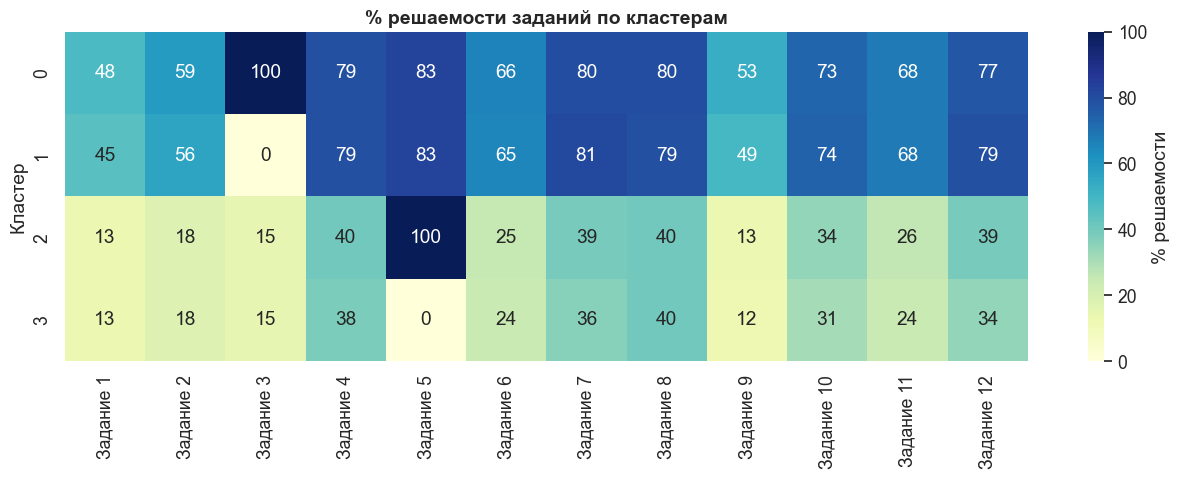

In [40]:
task_profile = (df.groupby('cluster')[task_correct_cols].mean() * 100).round(0)
task_profile = task_profile.rename(columns=task_labels)
task_profile.index.name = 'Кластер'

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(task_profile, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': '% решаемости'})
ax.set_title('% решаемости заданий по кластерам')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

Устойчивых поведенческих типов учеников в этих данных статистически не подтверждается.

## 13. Ключевые выводы и рекомендации

### Качество данных
- Исходные данные требовали очистки: 37 полных дублей строк, разнобой в написании регионов (19 вариантов на 10 реальных регионов), 73 тестовые сессии длительностью меньше минуты - удалены. Итоговый чистый датасет: 7 928 участников.
- Все остальные проверки прошли успешно: `total_score` полностью согласован с суммой правильных ответов, аномалий в классах и школах не найдено.

### Сложность заданий
- Самые сложные задания: Задание 1 (30%), Задание 9 (32%), Задание 3 (34%) решаемости.
- Самые лёгкие: Задание 5 (64%), Задание 8 (60%), Задание 4 (59%).
- Банк заданий сбалансирован: между заданиями нет дублирующих друг друга пар, ни отдельных, оторванных от всех. Пересматривать бланк заданий не требуется.
- На уровне заданий время и решаемость связаны почти линейно (сложные задания решают быстрее). Проверка на уровне учеников показала, что это не связано с поведением конкретных учеников, соответственно, дело в самих формулировках трёх самых сложных заданий. Требуется пересмотреть формулировки заданий 1, 9 и 3 перед следующим запуском.

### Аудитория
- Участники распределены равномерно по классам и регионам.
- Точность растёт равномерно от 5 к 11 классу. Сложность корректно масштабирована по возрасту.
- Почти треть участников (35%) заходит со смартфона.

### Регионы
- Видимый разброс среднего балла по регионам (от 5.38 до 5.73 из 12) — статистически не значим (ANOVA, p = 0.27; регион объясняет менее 0.2% различий). Не требуется адаптировать сложность олимпиады под конкретные регионы — уровень подготовки сопоставим по всей стране.

### Типажи учеников
- Попытка выделить поведенческие сегменты учеников (кластеризация) не дала устойчивого результата.

### Итоговые рекомендации для команды олимпиады
1. Пересмотреть формулировки трёх самых сложных заданий (1, 9, 3). Вероятная причина низкой решаемости не в сложности содержания, а в постановке вопроса.
2. Уделить внимание мобильному UX, т.к. треть аудитории проходит олимпиаду со смартфона.
3. Не тратить ресурсы на региональные версии заданий, т.к. региональной специфики нет.
4. Изучить причину 73 технических сессий (0.9% от всех прохождений).